In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
TARGET_BOROUGHS = ["BROOKLYN", "QUEENS", "MANHATTAN", "BRONX", "STATEN ISLAND"]
TARGET_GENDERS = ["M", "F"]

colors = ["#7f8c8d", "#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"]

sns.set_style("whitegrid")

In [3]:
#join
df_crashes = pd.read_csv("crashes.csv", low_memory=False)
df_vehicles = pd.read_csv("vehicles.csv", low_memory=False)

df_joined = pd.merge(df_crashes, df_vehicles, on="COLLISION_ID")

df_joined = df_joined[df_joined["DRIVER_SEX"].isin(TARGET_GENDERS)]
df_joined = df_joined.dropna(subset=["BOROUGH"])

print(f"Počet záznamů k analýze: {len(df_joined):,}")

Počet záznamů k analýze: 162,830


In [4]:
borough_gender_real = pd.crosstab(df_joined["BOROUGH"], df_joined["DRIVER_SEX"], normalize="index") * 100
print(borough_gender_real)

DRIVER_SEX             F          M
BOROUGH                            
BRONX          24.571237  75.428763
BROOKLYN       24.016285  75.983715
MANHATTAN      18.887145  81.112855
QUEENS         25.837663  74.162337
STATEN ISLAND  35.615385  64.384615


In [5]:
df_crashes.head()

,CRASH DATE,CRASH TIME,BOROUGH,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3
0,01/01/2024,17:07,BROOKLYN,0,0,Unspecified,Unspecified,4702082,Sedan,NaN,NaN
1,01/01/2024,10:00,NaN,1,0,Driver Inattention/Distraction,Unspecified,4691881,Station Wagon/Sport Utility Vehicle,Sedan,NaN
2,01/01/2024,21:56,BROOKLYN,2,0,Driver Inattention/Distraction,Driver Inattention/Distraction,4692079,Sedan,Sedan,NaN
3,01/01/2024,6:00,QUEENS,0,0,Unspecified,NaN,4691952,Sedan,NaN,NaN
4,01/01/2024,16:40,NaN,0,0,Unspecified,NaN,4692341,Sedan,NaN,NaN


In [6]:
df_vehicles.head()

,COLLISION_ID,CRASH_DATE,CRASH_TIME,VEHICLE_TYPE,VEHICLE_YEAR,VEHICLE_OCCUPANTS,DRIVER_SEX,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2
0,4691851,01/01/2024,1:10,Sedan,2021.0,1,M,Driver Inexperience,Tinted Windows
1,4691892,01/01/2024,3:30,Station Wagon/Sport Utility Vehicle,2011.0,0,NaN,Unspecified,Unspecified
2,4691821,01/01/2024,8:45,Station Wagon/Sport Utility Vehicle,2018.0,0,NaN,Unspecified,Unspecified
3,4691892,01/01/2024,3:30,Sedan,2014.0,1,NaN,Aggressive Driving/Road Rage,Unspecified
4,4692204,01/01/2024,5:20,Sedan,2023.0,0,NaN,Driver Inexperience,Unsafe Speed


In [7]:
df_joined.head()

,CRASH DATE,CRASH TIME,BOROUGH,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,CRASH_DATE,CRASH_TIME,VEHICLE_TYPE,VEHICLE_YEAR,VEHICLE_OCCUPANTS,DRIVER_SEX,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2
4,01/01/2024,21:56,BROOKLYN,2,0,Driver Inattention/Distraction,Driver Inattention/Distraction,4692079,Sedan,Sedan,NaN,01/01/2024,21:56,Sedan,2009.0,1,M,Driver Inattention/Distraction,Unspecified
5,01/01/2024,21:56,BROOKLYN,2,0,Driver Inattention/Distraction,Driver Inattention/Distraction,4692079,Sedan,Sedan,NaN,01/01/2024,21:56,Sedan,2019.0,1,M,Driver Inattention/Distraction,Unspecified
7,01/01/2024,6:00,QUEENS,0,0,Unspecified,NaN,4691952,Sedan,NaN,NaN,01/01/2024,6:00,Sedan,2024.0,1,M,Unspecified,Unspecified
11,01/01/2024,5:57,QUEENS,1,0,Unsafe Speed,Unspecified,4691606,E-Scooter,DELIVERY T,NaN,01/01/2024,5:57,E-Scooter,NaN,1,M,Unsafe Speed,Passing Too Closely
14,01/01/2024,15:38,QUEENS,0,0,Failure to Yield Right-of-Way,Unspecified,4692223,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,01/01/2024,15:38,Station Wagon/Sport Utility Vehicle,2020.0,1,M,Unspecified,Unspecified


In [8]:
TARGET_COLUMNS = [
    'COLLISION_ID', 
    'CRASH DATE', 
    'CRASH TIME', 
    'BOROUGH', 
    'DRIVER_SEX', 
    'CONTRIBUTING_FACTOR_1',
    'VEHICLE_TYPE'
]

df_clean = df_joined[TARGET_COLUMNS].copy()

print(f"Realita: Vybráno {len(TARGET_COLUMNS)} sloupců.")
print(f"Aktuální počet záznamů: {len(df_clean):,}")
df_clean.head()

Realita: Vybráno 7 sloupců.
Aktuální počet záznamů: 162,830


,COLLISION_ID,CRASH DATE,CRASH TIME,BOROUGH,DRIVER_SEX,CONTRIBUTING_FACTOR_1,VEHICLE_TYPE
4,4692079,01/01/2024,21:56,BROOKLYN,M,Driver Inattention/Distraction,Sedan
5,4692079,01/01/2024,21:56,BROOKLYN,M,Driver Inattention/Distraction,Sedan
7,4691952,01/01/2024,6:00,QUEENS,M,Unspecified,Sedan
11,4691606,01/01/2024,5:57,QUEENS,M,Unsafe Speed,E-Scooter
14,4692223,01/01/2024,15:38,QUEENS,M,Unspecified,Station Wagon/Sport Utility Vehicle


In [9]:
# DISTRIBUCE REALITY
print("--- DISTRIBUCE: ČTVRTI (BOROUGH) ---")
borough_dist = df_clean['BOROUGH'].value_counts(normalize=True) * 100
borough_dist = borough_dist.reindex(TARGET_BOROUGHS)
print(borough_dist.round(1))

print("\n--- DISTRIBUCE: POHLAVÍ (DRIVER SEX) ---")
sex_dist = df_clean['DRIVER_SEX'].value_counts(normalize=True) * 100
sex_dist = sex_dist.reindex(TARGET_GENDERS)
print(sex_dist.round(1))

--- DISTRIBUCE: ČTVRTI (BOROUGH) ---
BOROUGH
BROOKLYN         35.6
QUEENS           25.8
MANHATTAN        20.0
BRONX            14.7
STATEN ISLAND     4.0
Name: proportion, dtype: float64

--- DISTRIBUCE: POHLAVÍ (DRIVER SEX) ---
DRIVER_SEX
M    76.0
F    24.0
Name: proportion, dtype: float64


In [10]:
# načtení dat zero shot

def load_nyc_data(scenario, model_name):
    model_batches = []
    for i in range(1, 6):
        filename = f"{scenario}/{model_name}/crashes_{i}.csv"
        df = pd.read_csv(filename)
        
        df['DRIVER_SEX_CLEAN'] = df['DRIVER_SEX'].astype(str).str.upper().str[0]
        df['BOROUGH'] = df['BOROUGH'].astype(str).str.upper().str.strip()
        df["ITERATION"] = f"Batch {i}"
        
        model_batches.append(df)
            
    return pd.concat(model_batches, ignore_index=True)

df_claude = load_nyc_data("zero shot", "claude")
df_gpt = load_nyc_data("zero shot", "gpt")
df_gemini = load_nyc_data("zero shot", "gemini")
df_grok = load_nyc_data("zero shot", "grok")

In [11]:
df_gpt.head()

,COLLISION_ID,CRASH DATE,CRASH TIME,BOROUGH,DRIVER_SEX,CONTRIBUTING_FACTOR,VEHICLE_TYPE,DRIVER_SEX_CLEAN,ITERATION
0,1000000001,2024-01-03,07:14,BROOKLYN,M,Driver Inattention/Distraction,Sedan,M,Batch 1
1,1000000002,2024-01-05,18:22,BROOKLYN,F,Unsafe Speed,SUV,F,Batch 1
2,1000000003,2024-01-07,13:05,BROOKLYN,M,Following Too Closely,Pick-up Truck,M,Batch 1
3,1000000004,2024-01-09,22:41,BROOKLYN,NaN,Failure to Yield Right-of-Way,Sedan,N,Batch 1
4,1000000005,2024-01-12,08:33,BROOKLYN,M,Driver Inattention/Distraction,SUV,M,Batch 1


In [12]:
# konzistence zs

def check_consistency_gender(df, model_name):
    
    consistency = pd.crosstab(df["DRIVER_SEX_CLEAN"], df["ITERATION"], normalize="columns") * 100
    
    consistency = consistency.reindex(["M", "F"]).fillna(0)
    
    consistency['Max - Min'] = consistency.max(axis=1) - consistency.min(axis=1)
    
    print(f"\n--- KONZISTENCE ITERACÍ: {model_name.upper()} (Zero-Shot) ---")
    print(consistency.round(1))

check_consistency_gender(df_claude, "Claude")
check_consistency_gender(df_gpt, "GPT")
check_consistency_gender(df_gemini, "Gemini")
check_consistency_gender(df_grok, "Grok")


--- KONZISTENCE ITERACÍ: CLAUDE (Zero-Shot) ---
ITERATION         Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max - Min
DRIVER_SEX_CLEAN                                                        
M                    63.0     64.0     60.0     59.7     60.0        4.3
F                    30.3     29.0     30.0     29.7     32.3        3.3

--- KONZISTENCE ITERACÍ: GPT (Zero-Shot) ---
ITERATION         Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max - Min
DRIVER_SEX_CLEAN                                                        
M                    57.0     36.7     54.7     51.0     48.2       20.3
F                    29.7     36.7     37.0     47.0     44.9       17.3

--- KONZISTENCE ITERACÍ: GEMINI (Zero-Shot) ---
ITERATION         Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max - Min
DRIVER_SEX_CLEAN                                                        
M                    45.7     43.3     43.3     47.3     45.0        4.0
F                    36.3     40.3     39.0     34.7 

In [13]:
# spolehlivost zero shot

def audit_yield(df_list, names,):
    stats = []
    for df, name in zip(df_list, names):
        counts = df['ITERATION'].value_counts()
        stats.append({
            "Model": name,
            "Celkem": len(df),
            "Min/Batch": counts.min(),
            "Max/Batch": counts.max(),
            "Max - Min": counts.max() - counts.min()
        })
    return pd.DataFrame(stats).set_index("Model")

crashes_zs_dfs = [df_claude, df_gpt, df_gemini, df_grok]
print(audit_yield(crashes_zs_dfs, ["Claude", "GPT", "Gemini", "Grok"]).round(1))

        Celkem  Min/Batch  Max/Batch  Max - Min
Model                                          
Claude    1500        300        300          0
GPT       1501        300        301          1
Gemini    1500        300        300          0
Grok      1387        187        300        113


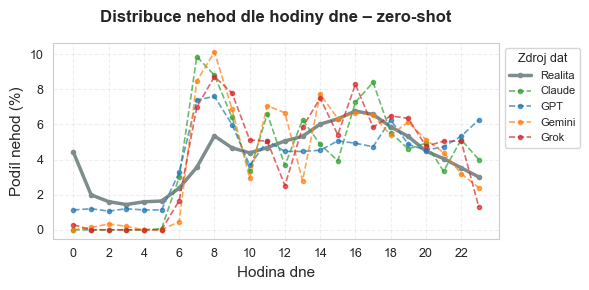

In [14]:
# ČASOVÁ distribuce

def get_hour_distribution(df):
    hours = pd.to_datetime(df['CRASH TIME'], format='mixed').dt.hour
    return hours.value_counts(normalize=True).sort_index() * 100

hours_real = get_hour_distribution(df_clean)
hours_claude = get_hour_distribution(df_claude)
hours_gpt = get_hour_distribution(df_gpt)
hours_gemini = get_hour_distribution(df_gemini)
hours_grok = get_hour_distribution(df_grok)

time_df = pd.DataFrame({
    "Realita": hours_real,
    "Claude": hours_claude,
    "GPT": hours_gpt,
    "Gemini": hours_gemini,
    "Grok": hours_grok
}).fillna(0)

# graf
plt.figure(figsize=(6, 3))

for i, col in enumerate(time_df.columns):
    is_real = (col == "Realita")
    
    linewidth = 2.5 if is_real else 1.2
    linestyle = '-' if is_real else '--'
    alpha = 1.0 if is_real else 0.7
    
    plt.plot(time_df.index, time_df[col], label=col, color=colors[i], 
             linewidth=linewidth, linestyle=linestyle, marker='o', 
             markersize=3, alpha=alpha)

plt.title("Distribuce nehod dle hodiny dne – zero-shot", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Hodina dne", fontsize=11)
plt.ylabel("Podíl nehod (%)", fontsize=11)

plt.xticks(range(0, 24, 2), fontsize=9)
plt.yticks(fontsize=9)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("nehody_casova_distribuce.svg")
plt.show()

In [15]:
# distribuce pohlaví

def get_sex_stats(df):
    filtered = df[df['DRIVER_SEX_CLEAN'].isin(TARGET_GENDERS)]
    return filtered['DRIVER_SEX_CLEAN'].value_counts(normalize=True) * 100

comparison_nyc = pd.DataFrame({
    "Realita": sex_dist,
    "Claude": get_sex_stats(df_claude),
    "GPT": get_sex_stats(df_gpt),
    "Gemini": get_sex_stats(df_gemini),
    "Grok": get_sex_stats(df_grok)
}).reindex(TARGET_GENDERS).fillna(0)

print(comparison_nyc.round(1))

   Realita  Claude   GPT  Gemini  Grok
M     76.0    67.0  55.9    54.8  60.8
F     24.0    33.0  44.1    45.2  39.2


In [16]:
def print_top_3(df_dict, gender, gender_name):
    for source_name, data in df_dict.items():
        is_real = True if source_name == 'Realita (NYC)' else False
        dist = get_factor_distribution(data, gender, is_real)
        
        print(f"\n[{source_name}]")
        if dist.empty:
            print("  Žádná data")
            continue
            
        for i, (factor, pct) in enumerate(dist.head(3).items(), 1):
            print(f"  {i}. {factor} ({pct:.1f} %)")

print("--- ZERO-SHOT: TEXTOVÝ VÝPIS TOP 3 PŘÍČIN ---")

def get_factor_distribution(df, gender, is_real=False):
    if df is None or df.empty: return pd.Series(dtype=float)
    
    factor_col = None
    for col in ['CONTRIBUTING_FACTOR', 'CONTRIBUTING_FACTOR_1']:
        if col in df.columns:
            factor_col = col
            break
            
    if not factor_col or 'DRIVER_SEX' not in df.columns: 
        return pd.Series(dtype=float)

    temp_df = df.copy()
    temp_df['SEX_CLEAN'] = temp_df['DRIVER_SEX'].astype(str).str.strip().str.upper()
    temp_df['FACTOR_CLEAN'] = temp_df[factor_col].astype(str).str.strip().str.title()

    temp_df = temp_df[(temp_df['SEX_CLEAN'] == gender) & (temp_df['FACTOR_CLEAN'].str.upper() != 'UNSPECIFIED')]

    return temp_df['FACTOR_CLEAN'].value_counts(normalize=True) * 100

--- ZERO-SHOT: TEXTOVÝ VÝPIS TOP 3 PŘÍČIN ---


In [17]:
data_sources = {
    'Realita (NYC)': df_clean,
    'Claude': df_claude,
    'GPT': df_gpt,
    'Gemini': df_gemini,
    'Grok': df_grok
}

print_top_3(data_sources, 'M', 'Muži')
print_top_3(data_sources, 'F', 'Ženy')


[Realita (NYC)]
  1. Driver Inattention/Distraction (31.9 %)
  2. Failure To Yield Right-Of-Way (10.0 %)
  3. Other Vehicular (6.7 %)

[Claude]
  1. Driver Inattention/Distraction (27.8 %)
  2. Unsafe Speed (17.0 %)
  3. Following Too Closely (13.6 %)

[GPT]
  1. Driver Inattention/Distraction (27.3 %)
  2. Unsafe Speed (21.0 %)
  3. Following Too Closely (13.3 %)

[Gemini]
  1. Driver Inattention/Distraction (24.0 %)
  2. Unsafe Speed (12.8 %)
  3. Following Too Closely (12.6 %)

[Grok]
  1. Driver Inattention/Distraction (29.2 %)
  2. Unsafe Speed (17.9 %)
  3. Failure To Yield Right-Of-Way (8.3 %)

[Realita (NYC)]
  1. Driver Inattention/Distraction (33.1 %)
  2. Failure To Yield Right-Of-Way (12.5 %)
  3. Other Vehicular (7.8 %)

[Claude]
  1. Driver Inattention/Distraction (37.2 %)
  2. Unsafe Speed (19.6 %)
  3. Failure To Yield Right-Of-Way (11.7 %)

[GPT]
  1. Failure To Yield Right-Of-Way (22.4 %)
  2. Following Too Closely (19.6 %)
  3. Driver Inattention/Distraction (14.5 %

In [18]:
# příčiny nehod fce
def plot_gender_causes(df_dict, gender, gender_name):
    all_dists = {}
    for name, df in df_dict.items():
        is_real = True if name == 'Realita (NYC)' else False
        all_dists[name] = get_factor_distribution(df, gender, is_real)
    
    combined_df = pd.DataFrame(all_dists).fillna(0)
    top_4_factors = combined_df.sum(axis=1).sort_values(ascending=False).head(4).index
    
    plot_df = combined_df.loc[top_4_factors].reset_index().melt(id_vars='FACTOR_CLEAN', var_name='Zdroj', value_name='Procento')
    plot_df.rename(columns={'FACTOR_CLEAN': 'Příčina nehody'}, inplace=True)
    
    plt.figure(figsize=(6, 3))
    
    ax = sns.barplot(data=plot_df, x='Příčina nehody', y='Procento', hue='Zdroj', palette=colors, edgecolor="black")
    
    plt.ylim(0, plot_df['Procento'].max() * 1.45)
    
    plt.title(f"Příčiny nehod: {gender_name} (zero-shot)", fontsize=12, fontweight="bold", pad=20)
    plt.ylabel("Podíl (%)", fontsize=11)
    plt.xlabel("Příčina", fontsize=11)
    
    plt.xticks(rotation=15, fontsize=9)
    plt.yticks(fontsize=9)
    
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.legend(title="Zdroj dat", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title_fontsize=9)
    
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.1f}%', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', 
                        fontsize=7,
                        rotation=90,
                        xytext=(0, 5), 
                        textcoords='offset points')
    
    plt.tight_layout()
    plt.savefig(f"priciny_nehod_{gender}_zs.svg")
    plt.show()

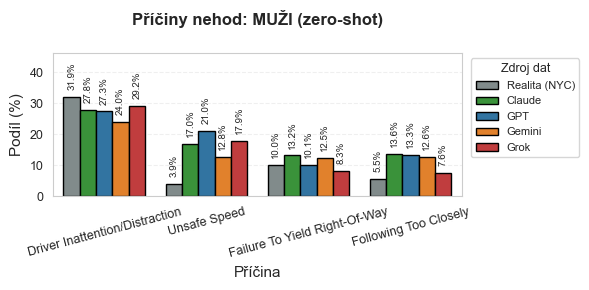

In [19]:
#graf
plot_gender_causes(data_sources, 'M', 'MUŽI')

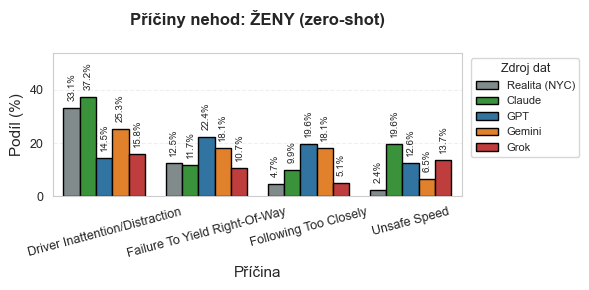

In [20]:
#graf
plot_gender_causes(data_sources, 'F', 'ŽENY')

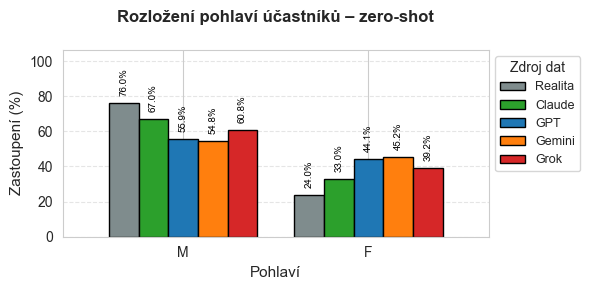

In [21]:
# graf
plt.figure(figsize=(6, 3))

ax = comparison_nyc.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black", 
    ax=plt.gca()
)

plt.ylim(0, comparison_nyc.values.max() * 1.4)

plt.title("Rozložení pohlaví účastníků – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Zastoupení (%)", fontsize=11)
plt.xlabel("Pohlaví", fontsize=11)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title="Zdroj dat", fontsize=9, title_fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.5)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', 
            fontsize=7,
            color='black', 
            xytext=(0, 5), 
            textcoords='offset points',
            rotation=90
        )

plt.tight_layout()
# Uložení jako bezztrátové SVG
plt.savefig("nehody_pohlavi_zs.svg")
plt.show()

In [22]:
#rozložení čtvrtí
def get_borough_stats(df):
    filtered = df[df['BOROUGH'].isin(TARGET_BOROUGHS)]
    return filtered['BOROUGH'].value_counts(normalize=True) * 100

borough_comp = pd.DataFrame({
    "Realita": get_borough_stats(df_clean),
    "Claude": get_borough_stats(df_claude),
    "GPT": get_borough_stats(df_gpt),
    "Gemini": get_borough_stats(df_gemini),
    "Grok": get_borough_stats(df_grok)
}).reindex(TARGET_BOROUGHS).fillna(0)

print("--- POROVNÁNÍ ČTVRTÍ (%) ---")
print(borough_comp.round(1))

--- POROVNÁNÍ ČTVRTÍ (%) ---
               Realita  Claude   GPT  Gemini  Grok
BOROUGH                                           
BROOKLYN          35.6    21.6  26.7    23.5  20.8
QUEENS            25.8    21.5  24.8    23.2  20.8
MANHATTAN         20.0    21.5  19.7    23.4  20.6
BRONX             14.7    21.3  18.4    16.3  20.5
STATEN ISLAND      4.0    14.1  10.4    13.7  17.2


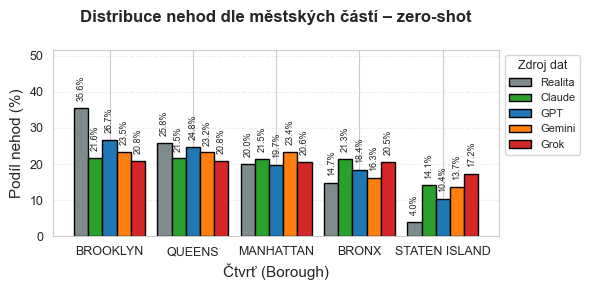

In [23]:
# graf
plt.figure(figsize=(6, 3)) # Šířka 16 cm

ax = borough_comp.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.85, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, borough_comp.values.max() * 1.45)

plt.title("Distribuce nehod dle městských částí – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl nehod (%)", fontsize=11)
plt.xlabel("Čtvrť (Borough)", fontsize=11)

plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=9)

plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=6.5,
            xytext=(0, 5), 
            textcoords='offset points', 
            rotation=90
        )

plt.tight_layout()
plt.savefig("nehody_ctvrti_zs.svg")
plt.show()

In [24]:
# příčiny nehod X pohlaví
def get_bias_stats(df, sex_col, factor_col):
    if df.empty: return 0.0, 0.0
    
    df_filtered = df[~df[factor_col].astype(str).str.contains('Unspecified', case=False, na=False)]
    if df_filtered.empty: return 0.0, 0.0
    
    m_mask = df_filtered[sex_col].astype(str).str.upper().str.startswith('M', na=False)
    f_mask = df_filtered[sex_col].astype(str).str.upper().str.startswith('F', na=False)
    
    speed_mask = df_filtered[factor_col].astype(str).str.contains('speed', case=False, na=False)
    dist_mask = df_filtered[factor_col].astype(str).str.contains('inattention|distraction', case=False, na=False)
    
    m_speed = (speed_mask & m_mask).sum() / m_mask.sum() * 100 if m_mask.sum() > 0 else 0.0
    f_dist = (dist_mask & f_mask).sum() / f_mask.sum() * 100 if f_mask.sum() > 0 else 0.0
    
    return m_speed, f_dist

# Výpočty
r_m, r_f = get_bias_stats(df_clean, 'DRIVER_SEX', 'CONTRIBUTING_FACTOR_1')
c_m, c_f = get_bias_stats(df_claude, 'DRIVER_SEX_CLEAN', 'CONTRIBUTING_FACTOR')
g_m, g_f = get_bias_stats(df_gpt, 'DRIVER_SEX_CLEAN', 'CONTRIBUTING_FACTOR')
m_m, m_f = get_bias_stats(df_gemini, 'DRIVER_SEX_CLEAN', 'CONTRIBUTING_FACTOR')
k_m, k_f = get_bias_stats(df_grok, 'DRIVER_SEX_CLEAN', 'CONTRIBUTING_FACTOR')

bias_df = pd.DataFrame({
    "Realita (Filtrováno)": [r_m, r_f],
    "Claude": [c_m, c_f],
    "GPT": [g_m, g_f],
    "Gemini": [m_m, m_f],
    "Grok": [k_m, k_f]
}, index=["Muži: Rychlost (Speed)", "Ženy: Nepozornost (Distraction)"])


print("POROVNÁNÍ OČIŠTĚNÝCH DAT (%)")
print(bias_df.round(1))

POROVNÁNÍ OČIŠTĚNÝCH DAT (%)
                                 Realita (Filtrováno)  Claude   GPT  Gemini  \
Muži: Rychlost (Speed)                            3.9    17.0  21.0    12.8   
Ženy: Nepozornost (Distraction)                  34.0    37.2  14.5    25.3   

                                 Grok  
Muži: Rychlost (Speed)           17.9  
Ženy: Nepozornost (Distraction)  23.5  


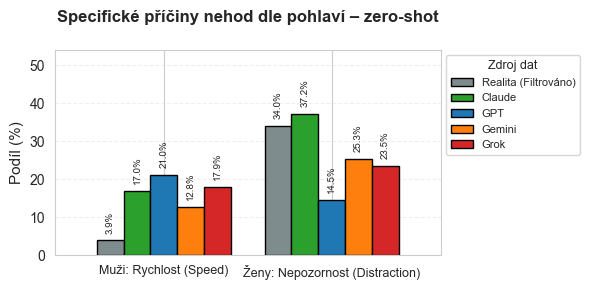

In [25]:
# graf
plt.figure(figsize=(6, 3))

ax = bias_df.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, bias_df.values.max() * 1.45)
plt.title("Specifické příčiny nehod dle pohlaví – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl (%)", fontsize=11)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width()/2., height), 
            ha='center', va='bottom', 
            fontsize=7,
            rotation=90,
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("nehody_bias_pohlavi_zs.svg")
plt.show()

In [26]:
# typ vozidel X pohlaví

def get_vehicle_stats(df, sex_col, vehicle_col):
    m_mask = df[sex_col].astype(str).str.upper().str.startswith('M', na=False)
    f_mask = df[sex_col].astype(str).str.upper().str.startswith('F', na=False)
    
    is_suv = df[vehicle_col].astype(str).str.contains('SUV|Sport Utility', case=False, na=False)
    is_sedan = df[vehicle_col].astype(str).str.contains('Sedan|Passenger', case=False, na=False)
    
    m_suv_pct = is_suv[m_mask].mean() * 100
    f_sedan_pct = is_sedan[f_mask].mean() * 100
    
    return m_suv_pct, f_sedan_pct

r_m_v, r_f_v = get_vehicle_stats(df_clean, 'DRIVER_SEX', 'VEHICLE_TYPE')
c_m_v, c_f_v = get_vehicle_stats(df_claude, 'DRIVER_SEX_CLEAN', 'VEHICLE_TYPE')
g_m_v, g_f_v = get_vehicle_stats(df_gpt, 'DRIVER_SEX_CLEAN', 'VEHICLE_TYPE')
m_m_v, m_f_v = get_vehicle_stats(df_gemini, 'DRIVER_SEX_CLEAN', 'VEHICLE_TYPE')
k_m_v, k_f_v = get_vehicle_stats(df_grok, 'DRIVER_SEX_CLEAN', 'VEHICLE_TYPE')

vehicle_df = pd.DataFrame({
    "Realita": [r_m_v, r_f_v],
    "Claude": [c_m_v, c_f_v],
    "GPT": [g_m_v, g_f_v],
    "Gemini": [m_m_v, m_f_v],
    "Grok": [k_m_v, k_f_v]
}, index=["Muži: SUV", "Ženy: Sedan"])

print("--- TYPY VOZIDEL (%) ---")
print(vehicle_df.round(1))

--- TYPY VOZIDEL (%) ---
             Realita  Claude   GPT  Gemini  Grok
Muži: SUV       28.3    21.2  30.3    29.2  35.0
Ženy: Sedan     49.8    42.7  38.7    52.8  30.8


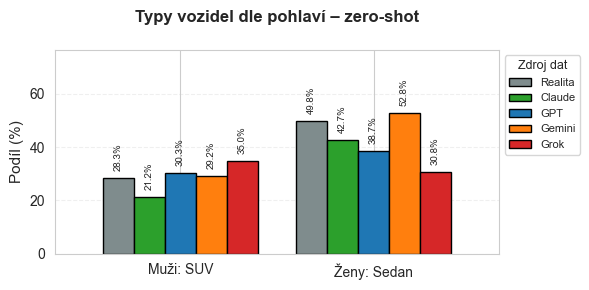

In [27]:
# GRAF: Typy vozidel dle pohlaví (Zero-Shot) - WORD READY
plt.figure(figsize=(6, 3))

ax = vehicle_df.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, vehicle_df.values.max() * 1.45)
plt.title("Typy vozidel dle pohlaví – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl (%)", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width()/2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("nehody_vozidla_pohlavi_zs.svg")
plt.show()

In [28]:
def load_nyc_adv(model_name):
    model_batches = []
    for i in range(1, 6):
        filename = f"few shot/{model_name}/crashes_adv_{i}.csv"
        df = pd.read_csv(filename)
        
        df['DRIVER_SEX_CLEAN'] = df['DRIVER_SEX'].astype(str).str.upper().str[0]
        df['BOROUGH'] = df['BOROUGH'].astype(str).str.upper().str.strip()
        df["ITERATION"] = f"Batch {i}"
        
        model_batches.append(df)
            
    return pd.concat(model_batches, ignore_index=True)

df_claude_adv = load_nyc_adv("claude")
df_gpt_adv = load_nyc_adv("gpt")
df_gemini_adv = load_nyc_adv("gemini")
df_grok_adv = load_nyc_adv("grok")

In [29]:
# konzistence ADV

check_consistency_gender(df_claude_adv, "Claude (ADV)")
check_consistency_gender(df_gpt_adv, "GPT (ADV)")
check_consistency_gender(df_gemini_adv, "Gemini (ADV)")
check_consistency_gender(df_grok_adv, "Grok (ADV)")


--- KONZISTENCE ITERACÍ: CLAUDE (ADV) (Zero-Shot) ---
ITERATION         Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max - Min
DRIVER_SEX_CLEAN                                                        
M                    80.3     77.3     78.0     78.3     77.4        3.0
F                    19.7     22.7     22.0     21.7     22.6        3.0

--- KONZISTENCE ITERACÍ: GPT (ADV) (Zero-Shot) ---
ITERATION         Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max - Min
DRIVER_SEX_CLEAN                                                        
M                    77.7     73.0     68.3     80.9     80.7       12.6
F                    22.3     27.0     31.7     19.1     19.3       12.6

--- KONZISTENCE ITERACÍ: GEMINI (ADV) (Zero-Shot) ---
ITERATION         Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max - Min
DRIVER_SEX_CLEAN                                                        
M                    80.0     75.7     80.7     78.3     80.7        5.0
F                    20.0     24.3 

In [30]:
# Konzistence ADV

crashes_fs_dfs = [df_claude_adv, df_gpt_adv, df_gemini_adv, df_grok_adv]
crashes_names = ["Claude", "GPT", "Gemini", "Grok"]

print(audit_yield(crashes_fs_dfs, crashes_names).round(1))

        Celkem  Min/Batch  Max/Batch  Max - Min
Model                                          
Claude    1664        300        464        164
GPT       1500        299        301          2
Gemini    1500        300        300          0
Grok      1500        300        300          0


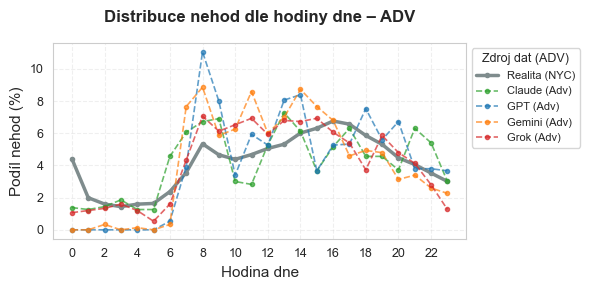

In [31]:
# časová distribuce ADV

hours_claude_adv = get_hour_distribution(df_claude_adv)
hours_gpt_adv = get_hour_distribution(df_gpt_adv)
hours_gemini_adv = get_hour_distribution(df_gemini_adv)
hours_grok_adv = get_hour_distribution(df_grok_adv)

time_df_adv = pd.DataFrame({
    "Realita (NYC)": hours_real,
    "Claude (Adv)": hours_claude_adv,
    "GPT (Adv)": hours_gpt_adv,
    "Gemini (Adv)": hours_gemini_adv,
    "Grok (Adv)": hours_grok_adv
}).fillna(0)

plt.figure(figsize=(6, 3))

for i, col in enumerate(time_df_adv.columns):
    is_real = (col == "Realita (NYC)")
    
    linewidth = 2.5 if is_real else 1.2
    linestyle = '-' if is_real else '--'
    alpha = 1.0 if is_real else 0.7
    
    plt.plot(time_df_adv.index, time_df_adv[col], label=col, color=colors[i], 
             linewidth=linewidth, linestyle=linestyle, marker='o', 
             markersize=3, alpha=alpha)

plt.title("Distribuce nehod dle hodiny dne – ADV", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Hodina dne", fontsize=11)
plt.ylabel("Podíl nehod (%)", fontsize=11)
plt.xticks(range(0, 24, 2), fontsize=9)
plt.yticks(fontsize=9)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Zdroj dat (ADV)", fontsize=8, title_fontsize=9, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("nehody_casova_distribuce_adv.svg")
plt.show()

In [32]:
# distribuce pohlaví

comparison_nyc_adv = pd.DataFrame({
    "Realita": sex_dist, 
    "Claude (ADV)": get_sex_stats(df_claude_adv),
    "GPT (ADV)": get_sex_stats(df_gpt_adv),
    "Gemini (ADV)": get_sex_stats(df_gemini_adv),
    "Grok (ADV)": get_sex_stats(df_grok_adv)
}).reindex(TARGET_GENDERS).fillna(0)

print(comparison_nyc_adv.round(1))

   Realita  Claude (ADV)  GPT (ADV)  Gemini (ADV)  Grok (ADV)
M     76.0          78.2       76.1          79.1        79.1
F     24.0          21.8       23.9          20.9        20.9


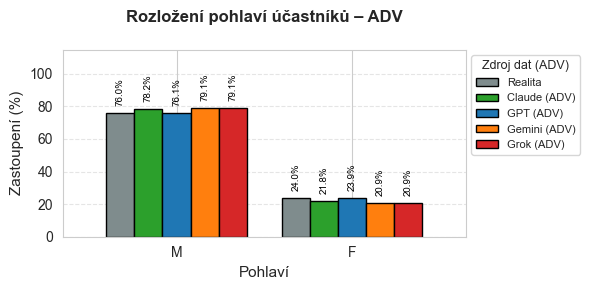

In [33]:
# graf
plt.figure(figsize=(6, 3))

ax = comparison_nyc_adv.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, comparison_nyc_adv.values.max() * 1.45)
plt.title("Rozložení pohlaví účastníků – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Zastoupení (%)", fontsize=11)
plt.xlabel("Pohlaví", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Zdroj dat (ADV)", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.5)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', 
            fontsize=7, 
            color='black', 
            xytext=(0, 5), 
            textcoords='offset points',
            rotation=90 
        )

plt.tight_layout()
plt.savefig("nehody_pohlavi_adv.svg")
plt.show()

In [34]:
# Distribuce čtvrtí

borough_comp_adv = pd.DataFrame({
    "Realita": get_borough_stats(df_clean),
    "Claude (ADV)": get_borough_stats(df_claude_adv),
    "GPT (ADV)": get_borough_stats(df_gpt_adv),
    "Gemini (ADV)": get_borough_stats(df_gemini_adv),
    "Grok (ADV)": get_borough_stats(df_grok_adv)
}).reindex(TARGET_BOROUGHS).fillna(0)

print("--- POROVNÁNÍ ADVANCED ČTVRTÍ (%) ---")
print(borough_comp_adv.round(1))

--- POROVNÁNÍ ADVANCED ČTVRTÍ (%) ---
               Realita  Claude (ADV)  GPT (ADV)  Gemini (ADV)  Grok (ADV)
BOROUGH                                                                  
BROOKLYN          35.6          34.4       27.4          29.2        30.5
QUEENS            25.8          21.7       21.8          25.5        24.8
MANHATTAN         20.0          19.4       21.9          22.1        21.3
BRONX             14.7          17.4       17.7          15.5        15.2
STATEN ISLAND      4.0           7.2       11.2           7.7         8.3


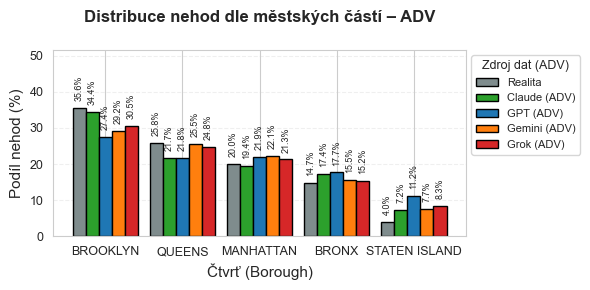

In [35]:
# graf
plt.figure(figsize=(6, 3))

ax = borough_comp_adv.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.85, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, borough_comp_adv.values.max() * 1.45)
plt.title("Distribuce nehod dle městských částí – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl nehod (%)", fontsize=11)
plt.xlabel("Čtvrť (Borough)", fontsize=11)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=9)
plt.legend(title="Zdroj dat (ADV)", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=6.5,
            xytext=(0, 5), 
            textcoords='offset points', 
            rotation=90
        )

plt.tight_layout()
plt.savefig("nehody_ctvrti_adv.svg")
plt.show()

In [36]:
# přičiny nehody X pohlaví

bias_df_adv = pd.DataFrame({
    "Realita":      get_bias_stats(df_clean, 'DRIVER_SEX', 'CONTRIBUTING_FACTOR_1'),
    "Claude (ADV)": get_bias_stats(df_claude_adv, 'DRIVER_SEX_CLEAN', 'CONTRIBUTING_FACTOR_1'),
    "GPT (ADV)":    get_bias_stats(df_gpt_adv, 'DRIVER_SEX_CLEAN', 'CONTRIBUTING_FACTOR_1'),
    "Gemini (ADV)": get_bias_stats(df_gemini_adv, 'DRIVER_SEX_CLEAN', 'CONTRIBUTING_FACTOR_1'),
    "Grok (ADV)":   get_bias_stats(df_grok_adv, 'DRIVER_SEX_CLEAN', 'CONTRIBUTING_FACTOR_1')
}, index=["Muži: Rychlost (Speed)", "Ženy: Nepozornost (Distraction)"]).fillna(0)

print(bias_df_adv.round(1))

                                 Realita  Claude (ADV)  GPT (ADV)  \
Muži: Rychlost (Speed)               3.9          15.2       23.7   
Ženy: Nepozornost (Distraction)     34.0          30.6       32.7   

                                 Gemini (ADV)  Grok (ADV)  
Muži: Rychlost (Speed)                    9.3        13.1  
Ženy: Nepozornost (Distraction)          38.2        29.0  


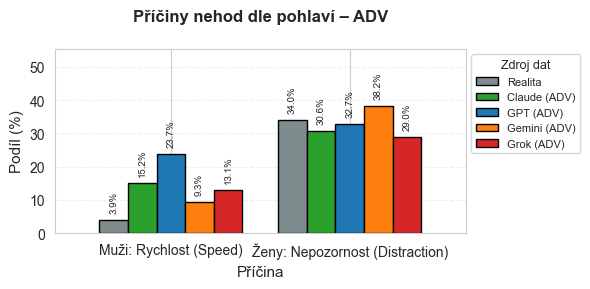

In [37]:
# graf
plt.figure(figsize=(6, 3))

ax = bias_df_adv.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, bias_df_adv.values.max() * 1.45)

plt.title("Příčiny nehod dle pohlaví – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl (%)", fontsize=11)
plt.xlabel("Příčina", fontsize=11)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("nehody_bias_adv.svg")
plt.show()

In [38]:
# typ vozidel X pohlaví

vehicle_df_adv = pd.DataFrame({
    "Realita":      get_vehicle_stats(df_clean, 'DRIVER_SEX', 'VEHICLE_TYPE'),
    "Claude (ADV)": get_vehicle_stats(df_claude_adv, 'DRIVER_SEX_CLEAN', 'VEHICLE_TYPE'),
    "GPT (ADV)":    get_vehicle_stats(df_gpt_adv, 'DRIVER_SEX_CLEAN', 'VEHICLE_TYPE'),
    "Gemini (ADV)": get_vehicle_stats(df_gemini_adv, 'DRIVER_SEX_CLEAN', 'VEHICLE_TYPE'),
    "Grok (ADV)":   get_vehicle_stats(df_grok_adv, 'DRIVER_SEX_CLEAN', 'VEHICLE_TYPE')
}, index=["Muži: SUV", "Ženy: Sedan"]).fillna(0)

print(vehicle_df_adv.round(1))

             Realita  Claude (ADV)  GPT (ADV)  Gemini (ADV)  Grok (ADV)
Muži: SUV       28.3          22.6       30.7          28.8        26.0
Ženy: Sedan     49.8          39.1       53.9          49.4        22.6


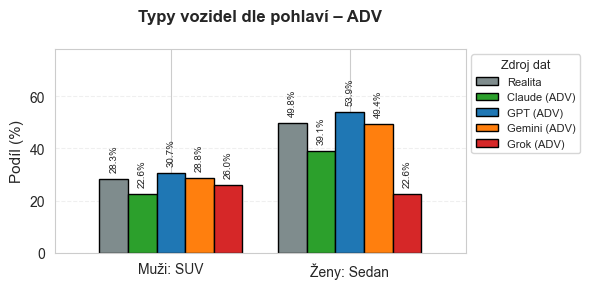

In [39]:
# graf
plt.figure(figsize=(6, 3))

ax = vehicle_df_adv.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=colors, 
    width=0.8, 
    edgecolor="black",
    ax=plt.gca()
)

plt.ylim(0, vehicle_df_adv.values.max() * 1.45)

plt.title("Typy vozidel dle pohlaví – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl (%)", fontsize=11)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title="Zdroj dat", fontsize=8, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=7, 
            rotation=90, 
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("nehody_vozidla_adv.svg", bbox_inches="tight")
plt.show()

In [40]:
data_sources_adv = {
    'Realita (NYC)': df_clean,
    'Claude (Adv)': df_claude_adv,
    'GPT (Adv)': df_gpt_adv,
    'Gemini (Adv)': df_gemini_adv,
    'Grok (Adv)': df_grok_adv
}

print_top_3(data_sources_adv, 'M', 'Muži')
print_top_3(data_sources_adv, 'F', 'Ženy')



[Realita (NYC)]
  1. Driver Inattention/Distraction (31.9 %)
  2. Failure To Yield Right-Of-Way (10.0 %)
  3. Other Vehicular (6.7 %)

[Claude (Adv)]
  1. Driver Inattention/Distraction (22.2 %)
  2. Unsafe Speed (15.2 %)
  3. Failure To Yield Right-Of-Way (11.7 %)

[GPT (Adv)]
  1. Driver Inattention/Distraction (34.9 %)
  2. Unsafe Speed (23.7 %)
  3. Following Too Closely (17.0 %)

[Gemini (Adv)]
  1. Driver Inattention/Distraction (33.5 %)
  2. Following Too Closely (13.9 %)
  3. Failure To Yield Right-Of-Way (13.2 %)

[Grok (Adv)]
  1. Driver Inattention/Distraction (25.4 %)
  2. Unsafe Speed (13.1 %)
  3. Failure To Yield Right-Of-Way (12.8 %)

[Realita (NYC)]
  1. Driver Inattention/Distraction (33.1 %)
  2. Failure To Yield Right-Of-Way (12.5 %)
  3. Other Vehicular (7.8 %)

[Claude (Adv)]
  1. Driver Inattention/Distraction (28.1 %)
  2. Unsafe Speed (16.0 %)
  3. Traffic Control Disregarded (9.4 %)

[GPT (Adv)]
  1. Driver Inattention/Distraction (32.7 %)
  2. Following Too 

In [41]:
# graf fce ADV
def plot_gender_causes_adv(df_dict, gender, gender_name):
    all_dists = {}
    for name, df in df_dict.items():
        is_real = True if name == 'Realita (NYC)' else False
        all_dists[name] = get_factor_distribution(df, gender, is_real)
    
    combined_df = pd.DataFrame(all_dists).fillna(0)
    top_4_factors = combined_df.sum(axis=1).sort_values(ascending=False).head(4).index
    
    plot_df = combined_df.loc[top_4_factors].reset_index().melt(id_vars='FACTOR_CLEAN', var_name='Zdroj', value_name='Procento')
    plot_df.rename(columns={'FACTOR_CLEAN': 'Příčina nehody'}, inplace=True)
    
    plt.figure(figsize=(6, 3))
    
    ax = sns.barplot(data=plot_df, x='Příčina nehody', y='Procento', hue='Zdroj', palette=colors, edgecolor="black")
    
    plt.ylim(0, plot_df['Procento'].max() * 1.45)
    
    plt.title(f"Příčiny nehod: {gender_name} (ADV)", fontsize=12, fontweight="bold", pad=20)
    plt.ylabel("Podíl (%)", fontsize=11)
    plt.xlabel("Příčina", fontsize=11)
    
    plt.xticks(rotation=15, fontsize=9)
    plt.yticks(fontsize=9)
    
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.legend(title="Zdroj dat", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title_fontsize=9)
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=7, 
                        rotation=90, 
                        xytext=(0, 5), 
                        textcoords='offset points')
    
    plt.tight_layout()
    plt.savefig(f"priciny_nehod_{gender}_adv.svg")
    plt.show()

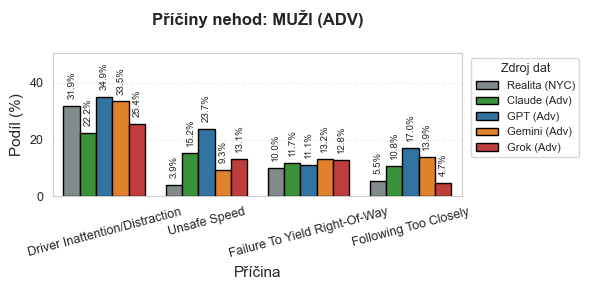

In [42]:
plot_gender_causes_adv(data_sources_adv, 'M', 'MUŽI')

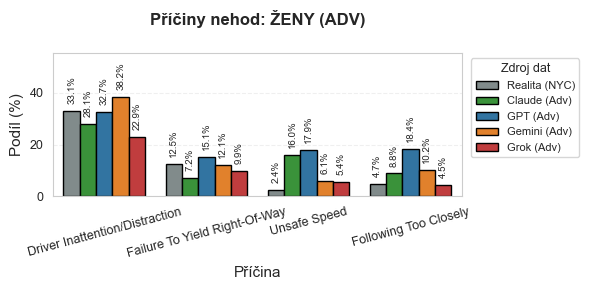

In [43]:
plot_gender_causes_adv(data_sources_adv, 'F', 'ŽENY')

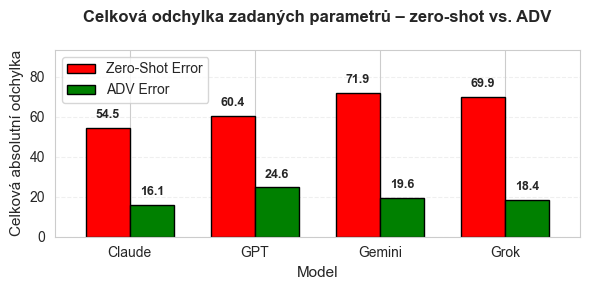

In [44]:
# Error rate

err_sex_zs = (comparison_nyc.drop(columns=["Realita"]).sub(comparison_nyc["Realita"], axis=0)).abs().sum()
err_sex_adv = (comparison_nyc_adv.drop(columns=["Realita"]).sub(comparison_nyc_adv["Realita"], axis=0)).abs().sum()

err_bor_zs = (borough_comp.drop(columns=["Realita"]).sub(borough_comp["Realita"], axis=0)).abs().sum()
err_bor_adv = (borough_comp_adv.drop(columns=["Realita"]).sub(borough_comp_adv["Realita"], axis=0)).abs().sum()

err_sex_adv.index = err_sex_adv.index.str.replace(" (ADV)", "", regex=False)
err_bor_adv.index = err_bor_adv.index.str.replace(" (ADV)", "", regex=False)

improvement_df = pd.DataFrame({
    "Zero-Shot Error": err_sex_zs + err_bor_zs,
    "ADV Error": err_sex_adv + err_bor_adv
})

# graf
plt.figure(figsize=(6, 3))

ax = improvement_df.plot(
    kind="bar", 
    figsize=(6, 3), 
    color=["red", "green"], 
    edgecolor="black", 
    width=0.7,
    ax=plt.gca()
)

plt.ylim(0, improvement_df.values.max() * 1.3)
plt.title("Celková odchylka zadaných parametrů – zero-shot vs. ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Celková absolutní odchylka", fontsize=11)
plt.xlabel("Model", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=9, 
            fontweight="bold",
            xytext=(0, 5), 
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig("error_rate_nyc.svg")
plt.show()